## Bad Debt Prediction

### Load the datasets

In [32]:
import pandas as pd
import numpy as np

In [33]:
# loading the datasets:

def load_data():
    print("Loading datasets....")

    data_df = pd.read_excel("Data.xlsm",sheet_name="DataV2")
    additional_df = pd.read_excel("Additional Info.xlsx",sheet_name="Additional info")

    print("Datasets loaded successfully !")

    print(f"\n Data dataset")
    print(data_df.head())

    print(f"\n Additional Dataset")
    print(additional_df.head())
    return data_df, additional_df

### Merging the datasets

In [34]:
def merge_data(data_df,additional_df):

    print("\nMerging datasets.....")

    merged_df = pd.merge(data_df,additional_df,on="Customer",how="left")
    print("Datasets merged successfully..")
    print("merged datasets shape:",merged_df.shape)

    return merged_df

# Load datasets
data_df, additional_df = load_data()

# Merge datasets
merged_df = merge_data(data_df,additional_df)

# View the merged data's
print("\n Merged datasets preview")
print(merged_df.head())    

def remove_rejected_records(df):

    print("Removing rejected records...")

    df = df[
        df["OUTCOME"] != "Rejected - Policy Decline"
    ]

    print("Rejected records removed successfully!")
    print(df["OUTCOME"].value_counts())

    return df

merged_df = merged_df[
    merged_df["OUTCOME"] != "Rejected - Policy Decline"
]

Loading datasets....
Datasets loaded successfully !

 Data dataset
  OUTCOME    Customer  RISK_SCORE BUREAU_ENQUIRIES_12_MONTHS  \
0    Good  2975536526         628      queries 12 Months 1-2   
1    Good  2999806086         813      queries 12 Months 1-2   
2    Good  2800835182        1012      queries 12 Months 4-5   
3    Good  2975640662         415      queries 12 Months 4-5   
4    Good  2979232086         556      queries 12 Months 1-2   

              LICENCE_AVAILABLE                    RESIDENTIAL  \
0  Driver Licence Check Missing                         Rented   
1      Driver Licence Check Yes                         Rented   
2      Driver Licence Check Yes                          Owned   
3  Driver Licence Check Missing                         Rented   
4  Driver Licence Check Missing  Board or Living With Relative   

             BUREAU_DEFAULT CD_OCCUPATION CD_STS_RESIDENTIAL  DEFAULT_AMT  \
0  Default Current- Missing             E                  R            0 

In [35]:
merged_df

,OUTCOME,Customer,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,...,WORST_24M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y,AGENCY_AMT,MTH_TILL_AGENCY
0,Good,2975536526,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,...,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R,NaN,NaN
1,Good,2999806086,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R,NaN,NaN
2,Good,2800835182,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,...,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O,NaN,NaN
3,Good,2975640662,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,...,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R,NaN,NaN
4,Good,2979232086,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,...,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B,60.01,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,Good,2999821794,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,...,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O,NaN,NaN
95305,Good,2811821694,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R,NaN,NaN
95306,Good,2971478930,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,...,0.0,AU Passport,Resident,S,F,0.0,125.0,O,NaN,NaN
95307,Bad,2974937898,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,...,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R,304.39,4.0


### Removing duplicates

In [36]:
def remove_duplicates(merged_df):
    print("Removing the duplicates....")

    merged_df = merged_df.drop_duplicates()
    print("Duplicates removed sucessfully...")
    print(f"Dataset shape : {merged_df.shape}")

    return merged_df
merged_df = remove_duplicates(merged_df)
print("Remaining duplicates :",merged_df.duplicated().sum())


Removing the duplicates....
Duplicates removed sucessfully...
Dataset shape : (92115, 98)
Remaining duplicates : 0


In [37]:
merged_df.shape

(92115, 98)

In [38]:
merged_df

,OUTCOME,Customer,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,...,WORST_24M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y,AGENCY_AMT,MTH_TILL_AGENCY
0,Good,2975536526,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,...,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R,NaN,NaN
1,Good,2999806086,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R,NaN,NaN
2,Good,2800835182,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,...,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O,NaN,NaN
3,Good,2975640662,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,...,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R,NaN,NaN
4,Good,2979232086,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,...,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B,60.01,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,Good,2999821794,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,...,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O,NaN,NaN
95305,Good,2811821694,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R,NaN,NaN
95306,Good,2971478930,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,...,0.0,AU Passport,Resident,S,F,0.0,125.0,O,NaN,NaN
95307,Bad,2974937898,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,...,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R,304.39,4.0


### View the column summary

In [39]:
def column_summary(df):

    summary_df = pd.DataFrame({
        "Column_Name": df.columns,
        "Data_Type": df.dtypes.values,
        "Null_Count": df.isnull().sum().values,
        "Null_Percentage": round((df.isnull().sum() / len(df)) * 100, 2).values,
        "Unique_Values": df.nunique().values
    })

    summary_df = summary_df.sort_values(
        by="Null_Percentage",
        ascending=False
    )

    return summary_df


# Generate report
summary_df = column_summary(merged_df)

# View report
print(summary_df)
'''
#Save report
summary_df.to_csv(
    "Column_Summary_Report.csv",
    index=False
) '''


         Column_Name Data_Type  Null_Count  Null_Percentage  Unique_Values
96        AGENCY_AMT   float64       83495            90.64           8011
97   MTH_TILL_AGENCY   float64       83495            90.64             20
91   EMPLOYED_STATUS       str       11102            12.05              9
92     EMPLOYED_TYPE       str       11102            12.05              5
93  EMPLOYED_NO_MTHS   float64       11102            12.05            373
..               ...       ...         ...              ...            ...
13      DEFAULTS_12M     int64           0             0.00              6
14  NO_MONTHS_VCR221     int64           0             0.00             13
15  NO_STATUS_VCR183    object           0             0.00             12
16     CD_STS_VCR184    object           0             0.00             11
17  NO_MONTHS_VCR228     int64           0             0.00             25

[98 rows x 5 columns]


'\n#Save report\nsummary_df.to_csv(\n    "Column_Summary_Report.csv",\n    index=False\n) '

### Dropping the unwanted columns

In [40]:
def drop_unwanted_columns(df):

    columns_to_drop = [
        "Customer",
        "WORST_3M",
        "WORST_1M",
        "WORST_18M",
        "WORST_12M",
        "WORST_24M",
        "MTH_TILL_AGENCY",
        "AGENCY_AMT"
    ]

    print("Dropping unwanted columns...")

    df = df.drop(columns =columns_to_drop,errors="ignore")

    print("Dropping the columns sucessfully..")
    print(f"Current shape : {df.shape}")
    return df

merged_df = drop_unwanted_columns(merged_df)
print(merged_df.columns.tolist())

Dropping unwanted columns...
Dropping the columns sucessfully..
Current shape : (92115, 90)
['OUTCOME', 'RISK_SCORE', 'BUREAU_ENQUIRIES_12_MONTHS', 'LICENCE_AVAILABLE', 'RESIDENTIAL', 'BUREAU_DEFAULT', 'CD_OCCUPATION', 'CD_STS_RESIDENTIAL_x', 'DEFAULT_AMT', 'ENQUIRIES_6M', 'ENQUIRIES_12M', 'DEROGATORIES', 'DEFAULTS_12M', 'NO_MONTHS_VCR221', 'NO_STATUS_VCR183', 'CD_STS_VCR184', 'NO_MONTHS_VCR228', 'NO_MONTHS_VCR226', 'NO_SUM_VCR053', 'NO_MONTHS_VCR258', 'SCORECARD', 'NO_SCORE', 'SCORE_INDICATOR_CR22', 'SCORE_CR22', 'SCORE_BAND_CR22', 'NO_SCORE_CR21', 'SCORECARD_CR21', 'RISK_RELATIVE_CR21', 'RISK_RELATIVE_ODDS_CR21', 'NO_MONTHS_OLDEST_ACCOUNT', 'OPEN_ACCT_CR22', 'CLOSED_ACCT_CR22', 'MORTGAGE_CR22', 'CREDIT_CARD_CR22', 'TELCO_CR22', 'UTILITIES_CR22', 'OVERDRAFT_CR22', 'PERSONAL_LOAN_CR22', 'AUTO_LOAN_CR22', 'CREDIT_CARD_AMT_CR22', 'OVERDRAFT_AMT_CR22', 'PERSONAL_LOAN_AMT_CR22', 'AUTO_LOAN_AMT_CR22', 'OPEN_ACCT_CR21', 'CLOSED_ACCT_CR21', 'MORTGAGE_CR21', 'CREDIT_CARD_CR21', 'TELCO_CR21', '

In [41]:
merged_df

,OUTCOME,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,ENQUIRIES_6M,...,DEFAULT_CNT_6M_CR21,DEFAULT_CNT_12M_CR21,WORST_6M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y
0,Good,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,2,...,0.0,0.0,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R
1,Good,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,2,...,0.0,0.0,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R
2,Good,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,5,...,0.0,0.0,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O
3,Good,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,2,...,0.0,0.0,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R
4,Good,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,2,...,0.0,0.0,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,Good,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,2,...,0.0,0.0,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O
95305,Good,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,3,...,0.0,0.0,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R
95306,Good,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,3,...,0.0,0.0,0.0,AU Passport,Resident,S,F,0.0,125.0,O
95307,Bad,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,2,...,0.0,0.0,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R


### Imputing the missing values using "Mode and Median"

In [42]:
def impute_missing_values(df):
    print("Imputing the missing values")

    # Numeric columns:
    numerical_cols = df.select_dtypes(include=["int64","float64"]).columns

    for col in numerical_cols:
        df[col] = df[col].fillna(df[col].median())

    # categoriacal columns:
    categorical_cols = df.select_dtypes(include=["object"]).columns

    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    print("Missiing values are Imputed successfully..")

    return df
merged_df = impute_missing_values(merged_df)
print(merged_df.isnull().sum().sum())


Imputing the missing values
Missiing values are Imputed successfully..
0


C:\Users\ompra\AppData\Local\Temp\ipykernel_11684\2243468637.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [43]:
merged_df.isnull().sum()

OUTCOME                       0
RISK_SCORE                    0
BUREAU_ENQUIRIES_12_MONTHS    0
LICENCE_AVAILABLE             0
RESIDENTIAL                   0
                             ..
EMPLOYED_STATUS               0
EMPLOYED_TYPE                 0
EMPLOYED_NO_MTHS              0
NO_ADDRESS_AT_MONTHS          0
CD_STS_RESIDENTIAL_y          0
Length: 90, dtype: int64

In [44]:
''''
merged_df.to_csv(
    "cleaned_data.csv",
    index=False
)

print("Cleaned dataset saved successfully.") '''

'\'\nmerged_df.to_csv(\n    "cleaned_data.csv",\n    index=False\n)\n\nprint("Cleaned dataset saved successfully.") '


### Spliting the Target variables:

In [45]:
def split_features_target(df,target_column):

    print("Separating the feature and target variables...")

    x = df.drop(columns=[target_column])
    y= df[target_column]

    print("Features shape :",x.shape)
    print("Target shape :",y.shape)

    return x,y

x,y = split_features_target(merged_df,target_column="OUTCOME")



Separating the feature and target variables...
Features shape : (92115, 89)
Target shape : (92115,)


In [46]:
print(y.unique())
print(y.value_counts())

<StringArray>
['Good', 'Bad']
Length: 2, dtype: str
OUTCOME
Good    84478
Bad      7637
Name: count, dtype: int64


## EDA

### Target Variable Analysis :

In [47]:
def analyze_target(y):
    print("Target variable distribution..")
    print("-" * 40)

    print(y.value_counts())

    print("\nPercentage Distribution")
    print(round(y.value_counts(normalize=True) * 100, 2 ))



def analyze_numerical_features(x):
    """
    Analyze numerical columns.
    """

    print("\n" + "=" * 50)
    print("NUMERICAL FEATURE ANALYSIS")
    print("=" * 50)

    numerical_df = x.select_dtypes(
        include=["int64", "float64"]
    )

    print(numerical_df.describe().T)


def analyze_categorical_features(x):
    """
    Analyze categorical columns.
    """

    print("\n" + "=" * 50)
    print("CATEGORICAL FEATURE ANALYSIS")
    print("=" * 50)

    categorical_cols = x.select_dtypes(
        include=["object"]
    ).columns

    for col in categorical_cols:

        print("\n" + "-" * 50)
        print(f"Column : {col}")
        print("-" * 50)

        print(x[col].value_counts())


def target_correlation_analysis(x, y):
    """
    Correlation of numerical features
    with target variable.
    """

    print("\n" + "=" * 50)
    print("TARGET CORRELATION ANALYSIS")
    print("=" * 50)

    temp_df = x.copy()

    temp_df["OUTCOME"] = y

    correlation_df = (
        temp_df.corr(
            numeric_only=True
        )["OUTCOME"]
        .sort_values(
            ascending=False
        )
    )

    print(correlation_df)

    return correlation_df


def run_eda(x, y):
    """
    Execute complete EDA workflow.
    """

    analyze_target(y)

    analyze_numerical_features(x)

    analyze_categorical_features(x)

    correlation_df = target_correlation_analysis(x,y)

    return correlation_df


In [48]:
x, y = split_features_target(
    merged_df,
    target_column="OUTCOME"
)

Separating the feature and target variables...
Features shape : (92115, 89)
Target shape : (92115,)


In [49]:
y = y.map({
    "Good": 0,
    "Bad": 1
})

In [50]:
correlation_df = run_eda(x, y)

Target variable distribution..
----------------------------------------
OUTCOME
0    84478
1     7637
Name: count, dtype: int64

Percentage Distribution
OUTCOME
0    91.71
1     8.29
Name: proportion, dtype: float64

NUMERICAL FEATURE ANALYSIS
                        count        mean          std    min    25%    50%  \
RISK_SCORE            92115.0  720.987038   180.711410 -125.0  614.0  660.0   
DEFAULT_AMT           92115.0  250.060077  4386.439734    0.0    0.0    0.0   
ENQUIRIES_6M          92115.0    2.611735     1.453608    1.0    2.0    2.0   
ENQUIRIES_12M         92115.0    2.993030     2.160077    1.0    2.0    2.0   
DEROGATORIES          92115.0    0.256408     1.405470    0.0    0.0    0.0   
...                       ...         ...          ...    ...    ...    ...   
DEFAULT_CNT_6M_CR21   92115.0    0.001476     0.043186    0.0    0.0    0.0   
DEFAULT_CNT_12M_CR21  92115.0    0.005613     0.086178    0.0    0.0    0.0   
WORST_6M              92115.0    0.277436    

C:\Users\ompra\AppData\Local\Temp\ipykernel_11684\3165039540.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(


OUTCOME                  1.000000
DEFAULT_OPEN_CNT_CR21    0.204732
DEFAULT_CNT_CR21         0.202649
DEROGATORIES             0.169665
WORST_6M                 0.127472
                           ...   
NO_SCORE_CR21           -0.210762
NO_SCORE                -0.214745
SCORE_CR22              -0.219520
RISK_SCORE              -0.223569
CREDIT_CARD_AMT_CR21          NaN
Name: OUTCOME, Length: 73, dtype: float64


In [51]:
# Check Remaining Categorical Columns

categorical_cols = x.select_dtypes(include = ["object"]).columns
print("Categorical Columns.")
print(categorical_cols.to_list())

Categorical Columns.
['BUREAU_ENQUIRIES_12_MONTHS', 'LICENCE_AVAILABLE', 'RESIDENTIAL', 'BUREAU_DEFAULT', 'CD_OCCUPATION', 'CD_STS_RESIDENTIAL_x', 'NO_STATUS_VCR183', 'CD_STS_VCR184', 'SCORECARD', 'SCORE_INDICATOR_CR22', 'SCORE_BAND_CR22', 'SCORECARD_CR21', 'DOC_TYPE', 'VISA_TYPE', 'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'CD_STS_RESIDENTIAL_y']


C:\Users\ompra\AppData\Local\Temp\ipykernel_11684\2415548192.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include = ["object"]).columns


In [52]:
# Analyze Cardinality
# Checking how many unique values each categorical column contains.

def analyze_categorical_columns(x):

    categorical_cols = x.select_dtypes(include=["object"])

    for col in categorical_cols:
        print("\n" + "=" * 50)
        print(f"Column : {col}")
        print("=" * 50)

        print(
            x[col].value_counts()
        )

        print(
            f"Unique Values : {x[col].nunique()}"
        )

analyze_categorical_columns(x)


Column : BUREAU_ENQUIRIES_12_MONTHS
BUREAU_ENQUIRIES_12_MONTHS
queries 12 Months 1-2      57265
queries 12 Months 3        13967
queries 12 Months 4-5      13182
queries 12 Months 6         2806
queries 12 Months 8-11      2539
queries 12 Months 7         1614
queries 12 Months 12-14      454
queries 12 Months 14+        288
Name: count, dtype: int64
Unique Values : 8

Column : LICENCE_AVAILABLE
LICENCE_AVAILABLE
Driver Licence Check Yes        56164
Driver Licence Check Missing    35722
Driver Licence Check No           229
Name: count, dtype: int64
Unique Values : 3

Column : RESIDENTIAL
RESIDENTIAL
Rented                                       49289
Owned                                        25377
Board or Living With Relative                 9685
Living At Home                                6177
Residential Missing Not Willing To Supply     1587
Name: count, dtype: int64
Unique Values : 5

Column : BUREAU_DEFAULT
BUREAU_DEFAULT
Default Current- Missing    87765
Default Current10

C:\Users\ompra\AppData\Local\Temp\ipykernel_11684\3868536597.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include=["object"])


Unique Values : 5

Column : CD_STS_RESIDENTIAL_y
CD_STS_RESIDENTIAL_y
R    51054
O    24353
L     5954
B     5293
W     4118
Z     1343
Name: count, dtype: int64
Unique Values : 6


In [53]:
#Next Step: Create a Feature Engineering Report

#Don't encode immediately.

#First create a report.


def categorical_feature_report(x):

    categorical_cols = x.select_dtypes(
        include=["object"]
    ).columns

    report = []

    for col in categorical_cols:

        report.append({
            "Column_Name": col,
            "Unique_Values": x[col].nunique(),
            "Most_Frequent_Value": x[col].mode()[0]
        })

    return pd.DataFrame(report)


cat_report = categorical_feature_report(x)

print(cat_report)

C:\Users\ompra\AppData\Local\Temp\ipykernel_11684\2977386533.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(


                   Column_Name  Unique_Values       Most_Frequent_Value
0   BUREAU_ENQUIRIES_12_MONTHS              8     queries 12 Months 1-2
1            LICENCE_AVAILABLE              3  Driver Licence Check Yes
2                  RESIDENTIAL              5                    Rented
3               BUREAU_DEFAULT              3  Default Current- Missing
4                CD_OCCUPATION             10                         E
5         CD_STS_RESIDENTIAL_x              7                         R
6             NO_STATUS_VCR183             12                         -
7                CD_STS_VCR184             11                         -
8                    SCORECARD              5                     TAR1A
9         SCORE_INDICATOR_CR22              2            Clean Positive
10             SCORE_BAND_CR22              9                         G
11              SCORECARD_CR21              5                     CTS1A
12                    DOC_TYPE              8         AU Driver 

In [54]:
#Create an encoding function.

def encode_categorical_features(x):

    print("Encoding categorical features...")

    x_encoded = pd.get_dummies(
        x,
        drop_first=True
    )

    print("Encoding completed.")
    print(f"Shape Before Encoding : {x.shape}")
    print(f"Shape After Encoding  : {x_encoded.shape}")

    return x_encoded

x_encoded = encode_categorical_features(x)

print(
    x_encoded.select_dtypes(
        include=["object","string"]
    ).columns.tolist()
)

Encoding categorical features...
Encoding completed.
Shape Before Encoding : (92115, 89)
Shape After Encoding  : (92115, 166)
[]


In [71]:
# removing CR 21 features
def identify_cr21_score_features(df):

    print("=" * 60)
    print("Identifying CR21 Score-related Features")
    print("=" * 60)

    keywords = [
        "SCORE_CR21",
        "RISK_SCORE_CR21",
        "NO_SCORE_CR21",
        "SCORECARD_CR21",
        "SCORE_BAND_CR21",
        "SCORE_INDICATOR_CR21"
    ]

    cr21_score_features = [
        col for col in df.columns
        if any(keyword in col for keyword in keywords)
    ]

    print(f"\nTotal Features Found : {len(cr21_score_features)}\n")

    for feature in cr21_score_features:
        print(feature)

    return cr21_score_features

cr21_score_features = identify_cr21_score_features(x_encoded)

Identifying CR21 Score-related Features

Total Features Found : 5

NO_SCORE_CR21
SCORECARD_CR21_CTSAD
SCORECARD_CR21_CTSDP
SCORECARD_CR21_CTSSH
SCORECARD_CR21_INSLV


In [72]:
def remove_cr21_score_features(df, features):

    print("\nRemoving CR21 Score-related Features...")

    updated_df = df.drop(columns=features)

    print("Removal Completed Successfully.")
    print(f"Old Shape : {df.shape}")
    print(f"New Shape : {updated_df.shape}")

    return updated_df
x_encoded = remove_cr21_score_features(
    x_encoded,
    cr21_score_features
)


Removing CR21 Score-related Features...
Removal Completed Successfully.
Old Shape : (92115, 166)
New Shape : (92115, 161)


In [73]:
remaining_features = [
    col for col in x_encoded.columns
    if any(keyword in col for keyword in [
        "SCORE_CR21",
        "RISK_SCORE_CR21",
        "NO_SCORE_CR21",
        "SCORECARD_CR21",
        "SCORE_BAND_CR21",
        "SCORE_INDICATOR_CR21"
    ])
]

print(remaining_features)

[]


In [55]:
# checking dtypes of the columns
print( x_encoded.dtypes.value_counts())

bool       94
float64    60
int64      12
Name: count, dtype: int64


In [74]:
x

,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,ENQUIRIES_6M,ENQUIRIES_12M,...,DEFAULT_CNT_6M_CR21,DEFAULT_CNT_12M_CR21,WORST_6M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y
0,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,2,2,...,0.0,0.0,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R
1,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,2,2,...,0.0,0.0,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R
2,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,5,5,...,0.0,0.0,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O
3,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,2,4,...,0.0,0.0,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R
4,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,2,2,...,0.0,0.0,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,2,2,...,0.0,0.0,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O
95305,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,3,6,...,0.0,0.0,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R
95306,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,3,3,...,0.0,0.0,0.0,AU Passport,Resident,S,F,0.0,125.0,O
95307,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,2,2,...,0.0,0.0,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R


In [75]:
print(x_encoded.head(10))

   RISK_SCORE  DEFAULT_AMT  ENQUIRIES_6M  ENQUIRIES_12M  DEROGATORIES  \
0         628            0             2              2             0   
1         813            0             2              2             0   
2        1012            0             5              5             0   
3         415          459             2              4             1   
4         556            0             2              2             0   
5         497          215             2              2             1   
6         626            0             2              2             0   
7         613            0             2              2             0   
8         603            0             2              2             0   
9         657            0             3              3             0   

   DEFAULTS_12M  NO_MONTHS_VCR221  NO_MONTHS_VCR228  NO_MONTHS_VCR226  \
0             0                 0                 0                 0   
1             0                 0                2

In [76]:
print("Shape:", x_encoded.shape)

Shape: (92115, 161)


## EDA Visualization

### Target Variable Distribution :

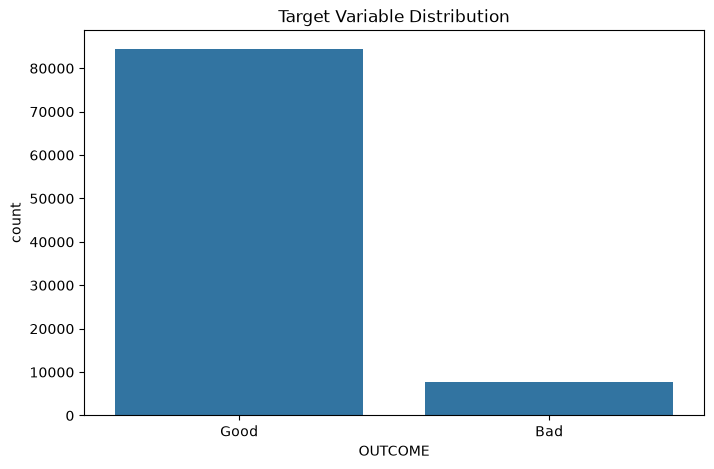

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="OUTCOME"
)

plt.title("Target Variable Distribution")
plt.show()

### Risk Score Distribution

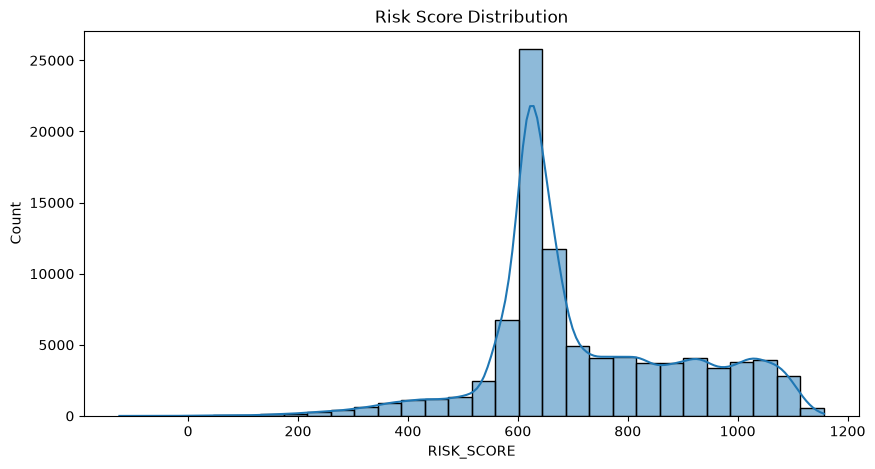

In [78]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["RISK_SCORE"],
    bins=30,
    kde=True
)

plt.title("Risk Score Distribution")
plt.show()

### Risk Score vs Outcome :

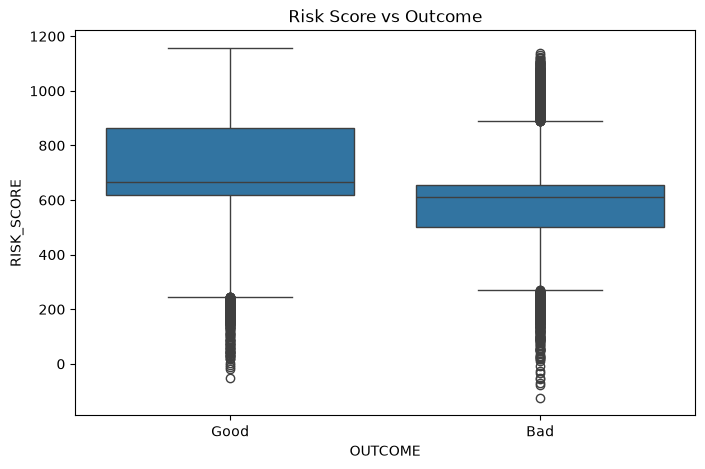

In [79]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x="OUTCOME",
    y="RISK_SCORE"
)

plt.title("Risk Score vs Outcome")
plt.show()

### Top 20 Important Features :

In [62]:
'''top20 = feature_importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.show()'''

'top20 = feature_importance.head(20)\n\nplt.figure(figsize=(12,8))\n\nsns.barplot(\n    data=top20,\n    x="Importance",\n    y="Feature"\n)\n\nplt.title("Top 20 Important Features")\nplt.show()'

## Feature Engineering

### Feature Selection

In [80]:
## Random forest classifier



from sklearn.ensemble import RandomForestClassifier


def create_feature_subsets(x, y):

    print("Training Random Forest for Feature Selection...")

    # Train Random Forest
    rf_selector = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf_selector.fit(x, y)

    print("Feature Selection Model Trained Successfully.")

    # Feature Importance
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": rf_selector.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    # Create Feature Lists
    top_10_features = feature_importance.head(10)["Feature"].tolist()

    top_20_features = feature_importance.head(20)["Feature"].tolist()

    top_30_features = feature_importance.head(30)["Feature"].tolist()

    top_40_features = feature_importance.head(40)["Feature"].tolist()

    top_50_features = feature_importance.head(50)["Feature"].tolist()

    # Create Feature Subsets
    x_top10 = x[top_10_features]

    x_top20 = x[top_20_features]

    x_top30 = x[top_30_features]

    x_top40 = x[top_40_features]

    x_top50 = x[top_50_features]

    return {
        "Feature_Importance": feature_importance,
        "Top10": x_top10,
        "Top20": x_top20,
        "Top30": x_top30,
        "Top40": x_top40,
        "Top50": x_top50
    }


# Run Feature Selection
results = create_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
feature_importance = results["Feature_Importance"]

x_top10 = results["Top10"]

x_top20 = results["Top20"]

x_top30 = results["Top30"]

x_top40 = results["Top40"]

x_top50 = results["Top50"]


# View Top Features
print("\nTop 20 Important Features")
print(feature_importance.head(20))


# Verify Shapes
print("\nDataset Shapes")

print("Top 10 :", x_top10.shape)

print("Top 20 :", x_top20.shape)

print("Top 30 :", x_top30.shape)

print("Top 40 :", x_top40.shape)

print("Top 50 :", x_top50.shape)



Training Random Forest for Feature Selection...
Feature Selection Model Trained Successfully.

Top 20 Important Features
                     Feature  Importance
0                 SCORE_CR22    0.178633
1       NO_ADDRESS_AT_MONTHS    0.073178
2                 RISK_SCORE    0.058385
3           EMPLOYED_NO_MTHS    0.050374
4                   NO_SCORE    0.043340
5    RISK_RELATIVE_ODDS_CR21    0.039543
6         RISK_RELATIVE_CR21    0.037846
7   NO_MONTHS_OLDEST_ACCOUNT    0.019473
8           ENQUIRY_CNT_CR21    0.015740
9              NO_SUM_VCR053    0.015487
10          ENQUIRY_CNT_CR22    0.014082
11          NO_MONTHS_VCR228    0.013970
12               DEFAULT_AMT    0.012164
13             ENQUIRIES_12M    0.011229
14              ENQUIRIES_6M    0.010517
15   DEFAULT_UNPAID_AMT_CR21    0.008893
16   DEFAULT_UNPAID_AMT_CR22    0.008614
17              DEROGATORIES    0.008483
18       ENQUIRY_MAX_AMT_12M    0.008452
19                  WORST_6M    0.008290

Dataset Shapes
To

In [81]:

# Mutual Information Feature Selection..


from sklearn.feature_selection import mutual_info_classif


def create_mi_feature_subsets(x, y):

    print("Calculating Mutual Information Scores...")

    # Calculate MI Scores
    mi_scores = mutual_info_classif(
        x,
        y,
        random_state=42
    )

    print("Mutual Information Calculation Completed.")

    # Create Importance DataFrame
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": mi_scores
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    # Create Feature Lists
    top_10_features = feature_importance.head(10)["Feature"].tolist()

    top_20_features = feature_importance.head(20)["Feature"].tolist()

    top_30_features = feature_importance.head(30)["Feature"].tolist()

    top_40_features = feature_importance.head(40)["Feature"].tolist()

    top_50_features = feature_importance.head(50)["Feature"].tolist()

    # Create Feature Subsets
    x_top10 = x[top_10_features]

    x_top20 = x[top_20_features]

    x_top30 = x[top_30_features]

    x_top40 = x[top_40_features]

    x_top50 = x[top_50_features]

    return {
        "Feature_Importance": feature_importance,
        "Top10": x_top10,
        "Top20": x_top20,
        "Top30": x_top30,
        "Top40": x_top40,
        "Top50": x_top50
    }


# Run Feature Selection
results_mi = create_mi_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
mi_feature_importance = results_mi["Feature_Importance"]

x_top10_mi = results_mi["Top10"]

x_top20_mi = results_mi["Top20"]

x_top30_mi = results_mi["Top30"]

x_top40_mi = results_mi["Top40"]

x_top50_mi = results_mi["Top50"]


# View Top Features
print("\nTop 20 Mutual Information Features")
print(mi_feature_importance.head(20))


# Verify Shapes
print("\nDataset Shapes")

print("Top 10 :", x_top10_mi.shape)

print("Top 20 :", x_top20_mi.shape)

print("Top 30 :", x_top30_mi.shape)

print("Top 40 :", x_top40_mi.shape)

print("Top 50 :", x_top50_mi.shape)

Calculating Mutual Information Scores...
Mutual Information Calculation Completed.

Top 20 Mutual Information Features
                                       Feature  Importance
0                                   RISK_SCORE    0.029544
1                                   SCORE_CR22    0.028187
2                                     NO_SCORE    0.026533
3                           RISK_RELATIVE_CR21    0.024470
4                      RISK_RELATIVE_ODDS_CR21    0.024417
5                           NO_STATUS_VCR183_-    0.021874
6                          ENQUIRY_CNT_3M_CR22    0.021704
7   LICENCE_AVAILABLE_Driver Licence Check Yes    0.018425
8                                 DEROGATORIES    0.018375
9                   DOC_TYPE_AU Driver Licence    0.017829
10                           EMPLOYED_STATUS_E    0.016891
11                      CD_STS_RESIDENTIAL_y_R    0.016813
12                         ENQUIRY_CNT_6M_CR22    0.016672
13                         ENQUIRY_CNT_1M_CR21    0.015

In [82]:
#XGBoost Feature Selection

from xgboost import XGBClassifier


def create_xgb_feature_subsets(x, y):

    print("Training XGBoost for Feature Selection...")

    xgb_selector = XGBClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )

    xgb_selector.fit(x, y)

    print("XGBoost Feature Selection Completed.")

    # Feature Importance
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": xgb_selector.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    # Create Feature Lists
    top_10_features = feature_importance.head(10)["Feature"].tolist()

    top_20_features = feature_importance.head(20)["Feature"].tolist()

    top_30_features = feature_importance.head(30)["Feature"].tolist()

    top_40_features = feature_importance.head(40)["Feature"].tolist()

    top_50_features = feature_importance.head(50)["Feature"].tolist()

    # Create Feature Subsets
    x_top10 = x[top_10_features]

    x_top20 = x[top_20_features]

    x_top30 = x[top_30_features]

    x_top40 = x[top_40_features]

    x_top50 = x[top_50_features]

    return {
        "Feature_Importance": feature_importance,
        "Top10": x_top10,
        "Top20": x_top20,
        "Top30": x_top30,
        "Top40": x_top40,
        "Top50": x_top50
    }


# Run Feature Selection
results_xgb = create_xgb_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
xgb_feature_importance = results_xgb["Feature_Importance"]

x_top10_xgb = results_xgb["Top10"]

x_top20_xgb = results_xgb["Top20"]

x_top30_xgb = results_xgb["Top30"]

x_top40_xgb = results_xgb["Top40"]

x_top50_xgb = results_xgb["Top50"]

# View Results
print("\nTop 20 XGBoost Features")
print(xgb_feature_importance.head(20))

print("\nDataset Shapes")
print("Top10 :", x_top10_xgb.shape)
print("Top20 :", x_top20_xgb.shape)
print("Top30 :", x_top30_xgb.shape)
print("Top40 :", x_top40_xgb.shape)
print("Top50 :", x_top50_xgb.shape)

Training XGBoost for Feature Selection...
XGBoost Feature Selection Completed.

Top 20 XGBoost Features
                                       Feature  Importance
0                                   RISK_SCORE    0.052910
1                   DOC_TYPE_AU Driver Licence    0.030810
2                                   SCORE_CR22    0.021118
3          SCORE_INDICATOR_CR22_Dirty Positive    0.018760
4                         DOC_TYPE_AU Passport    0.018335
5                       CD_STS_RESIDENTIAL_x_L    0.017423
6                            EMPLOYED_STATUS_U    0.015543
7                                  DEFAULT_AMT    0.014019
8                              CD_OCCUPATION_E    0.012109
9                            VISA_TYPE_Student    0.011538
10                     DEFAULT_UNPAID_AMT_CR21    0.011311
11                      DOC_TYPE_HAAU 18+ Card    0.010633
12  LICENCE_AVAILABLE_Driver Licence Check Yes    0.010592
13                                    NO_SCORE    0.010571
14         

In [83]:

# RFE (Recursive Feature Elimination) Feature Selection

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


def create_rfe_feature_subsets(x, y):

    print("Running Recursive Feature Elimination...")

    base_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    selector = RFE(
        estimator=base_model,
        n_features_to_select=50,
        step=5
    )

    selector.fit(x, y)

    print("RFE Completed Successfully.")

    feature_ranking = pd.DataFrame({
        "Feature": x.columns,
        "Rank": selector.ranking_
    })

    feature_ranking = (
        feature_ranking
        .sort_values(
            by="Rank",
            ascending=True
        )
        .reset_index(drop=True)
    )

    # Create Feature Lists
    top_10_features = (
        feature_ranking
        .head(10)["Feature"]
        .tolist()
    )

    top_20_features = (
        feature_ranking
        .head(20)["Feature"]
        .tolist()
    )

    top_30_features = (
        feature_ranking
        .head(30)["Feature"]
        .tolist()
    )

    top_40_features = (
        feature_ranking
        .head(40)["Feature"]
        .tolist()
    )

    top_50_features = (
        feature_ranking
        .head(50)["Feature"]
        .tolist()
    )

    return {
        "Feature_Ranking": feature_ranking,
        "Top10": x[top_10_features],
        "Top20": x[top_20_features],
        "Top30": x[top_30_features],
        "Top40": x[top_40_features],
        "Top50": x[top_50_features]
    }


# Run RFE
results_rfe = create_rfe_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
rfe_feature_ranking = results_rfe["Feature_Ranking"]

x_top10_rfe = results_rfe["Top10"]

x_top20_rfe = results_rfe["Top20"]

x_top30_rfe = results_rfe["Top30"]

x_top40_rfe = results_rfe["Top40"]

x_top50_rfe = results_rfe["Top50"]

# View Results
print("\nTop 20 RFE Features")
print(rfe_feature_ranking.head(20))

print("\nDataset Shapes")

print("Top10 :", x_top10_rfe.shape)
print("Top20 :", x_top20_rfe.shape)
print("Top30 :", x_top30_rfe.shape)
print("Top40 :", x_top40_rfe.shape)
print("Top50 :", x_top50_rfe.shape)
rfe_feature_ranking.head(20)

Running Recursive Feature Elimination...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

RFE Completed Successfully.

Top 20 RFE Features
                                Feature  Rank
0                         MORTGAGE_CR21     1
1                        OVERDRAFT_CR22     1
2                    PERSONAL_LOAN_CR22     1
3                        OPEN_ACCT_CR21     1
4                      CREDIT_CARD_CR22     1
5                        AUTO_LOAN_CR21     1
6                        UTILITIES_CR21     1
7                        OVERDRAFT_CR21     1
8                 DEFAULT_OPEN_CNT_CR21     1
9                  DEFAULT_CNT_12M_CR22     1
10                     DEFAULT_CNT_CR21     1
11  SCORE_INDICATOR_CR22_Dirty Positive     1
12                     SCORECARD_HSHSOL     1
13                      SCORECARD_TAR1A     1
14                      CD_STS_VCR184_2     1
15                      CD_STS_VCR184_1     1
16               CD_STS_RESIDENTIAL_x_W     1
17                   NO_STATUS_VCR183_2     1
18                   NO_STATUS_VCR183_N     1
19                   NO_STATUS_

,Feature,Rank
0,MORTGAGE_CR21,1
1,OVERDRAFT_CR22,1
2,PERSONAL_LOAN_CR22,1
3,OPEN_ACCT_CR21,1
4,CREDIT_CARD_CR22,1
5,AUTO_LOAN_CR21,1
6,UTILITIES_CR21,1
7,OVERDRAFT_CR21,1
8,DEFAULT_OPEN_CNT_CR21,1
9,DEFAULT_CNT_12M_CR22,1


In [85]:
#LightGBM Feature Importance.

from lightgbm import LGBMClassifier


def create_lgbm_feature_subsets(x, y):

    print("Training LightGBM for Feature Selection...")

    lgbm_selector = LGBMClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgbm_selector.fit(x, y)

    print("LightGBM Feature Selection Completed.")

    # Feature Importance
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": lgbm_selector.feature_importances_
    })

    feature_importance = (
        feature_importance
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # Top Feature Lists
    top_10_features = feature_importance.head(10)["Feature"].tolist()

    top_20_features = feature_importance.head(20)["Feature"].tolist()

    top_30_features = feature_importance.head(30)["Feature"].tolist()

    top_40_features = feature_importance.head(40)["Feature"].tolist()

    top_50_features = feature_importance.head(50)["Feature"].tolist()

    return {
        "Feature_Importance": feature_importance,
        "Top10": x[top_10_features],
        "Top20": x[top_20_features],
        "Top30": x[top_30_features],
        "Top40": x[top_40_features],
        "Top50": x[top_50_features]
    }


# Run Feature Selection
results_lgbm = create_lgbm_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
lgbm_feature_importance = results_lgbm["Feature_Importance"]

x_top10_lgbm = results_lgbm["Top10"]

x_top20_lgbm = results_lgbm["Top20"]

x_top30_lgbm = results_lgbm["Top30"]

x_top40_lgbm = results_lgbm["Top40"]

x_top50_lgbm = results_lgbm["Top50"]

# View Results
print("\nTop 20 LightGBM Features")
print(lgbm_feature_importance.head(20))

print("\nDataset Shapes")

print("Top10 :", x_top10_lgbm.shape)
print("Top20 :", x_top20_lgbm.shape)
print("Top30 :", x_top30_lgbm.shape)
print("Top40 :", x_top40_lgbm.shape)
print("Top50 :", x_top50_lgbm.shape)

Training LightGBM for Feature Selection...
LightGBM Feature Selection Completed.

Top 20 LightGBM Features
                     Feature  Importance
0                 SCORE_CR22         254
1       NO_ADDRESS_AT_MONTHS         184
2                 RISK_SCORE         182
3                   NO_SCORE         169
4   NO_MONTHS_OLDEST_ACCOUNT         161
5           EMPLOYED_NO_MTHS         116
6         RISK_RELATIVE_CR21         114
7              NO_SUM_VCR053          95
8        ENQUIRY_MAX_AMT_12M          81
9           ENQUIRY_CNT_CR21          66
10          ENQUIRY_CNT_CR22          61
11        ENQUIRY_MAX_AMT_3M          52
12              ENQUIRIES_6M          46
13          NO_MONTHS_VCR228          46
14      CREDIT_CARD_AMT_CR22          43
15   DEFAULT_UNPAID_AMT_CR22          42
16          NO_MONTHS_VCR258          36
17           CD_OCCUPATION_E          36
18               DEFAULT_AMT          34
19          CLOSED_ACCT_CR21          34

Dataset Shapes
Top10 : (92115, 

In [ ]:
# save the feature engineering features.
'''                                                # Commenting this module because if i run again it shows error.
feature_importance.to_csv(
    "RandomForest_Feature_Importance.csv",
    index=False
)

mi_feature_importance.to_csv(
    "MutualInformation_Feature_Importance.csv",
    index=False
)

xgb_feature_importance.to_csv(
    "XGBoost_Feature_Importance.csv",
    index=False
)

rfe_feature_ranking.to_csv(
    "RFE_Feature_Ranking.csv",
    index=False
)

lgbm_feature_importance.to_csv(
    "LightGBM_Feature_Importance.csv",
    index=False
) 

x_encoded.to_csv(
    "feature_engineered_dataset.csv",
    index=False
)'''
 

In [87]:
#Lowest Importance
feature_importance.tail(10)

,Feature,Importance
151,CD_STS_VCR184_5,0.000131
152,CD_STS_VCR184_X,0.000112
153,DOC_TYPE_Defence Force ID(picture card),0.000103
154,NO_STATUS_VCR183_X,0.000055
155,CREDIT_CARD_CR21,0.000049
156,CD_STS_VCR184_H,0.000048
157,NO_STATUS_VCR183_H,0.000047
158,CD_STS_VCR184_6,0.000034
159,DEFAULT_CNT_3M_CR21,0.000001
160,CREDIT_CARD_AMT_CR21,0.000000


In [88]:
# Highest Importance
feature_importance.head(10)

,Feature,Importance
0,SCORE_CR22,0.178633
1,NO_ADDRESS_AT_MONTHS,0.073178
2,RISK_SCORE,0.058385
3,EMPLOYED_NO_MTHS,0.050374
4,NO_SCORE,0.043340
5,RISK_RELATIVE_ODDS_CR21,0.039543
6,RISK_RELATIVE_CR21,0.037846
7,NO_MONTHS_OLDEST_ACCOUNT,0.019473
8,ENQUIRY_CNT_CR21,0.015740
9,NO_SUM_VCR053,0.015487


### Model Evaluvation

In [92]:
from sklearn.model_selection import train_test_split


def create_train_test_splits(feature_sets, y, test_size=0.2, random_state=42):

    print("=" * 70)
    print("Creating Train-Test Splits")
    print("=" * 70)

    split_datasets = {}

    for dataset_name, X in feature_sets.items():

        print(f"\nProcessing {dataset_name} Dataset...")

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=y
        )

        split_datasets[dataset_name] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }

        print(f"Training Shape : {X_train.shape}")
        print(f"Testing Shape  : {X_test.shape}")

    print("\nTrain-Test Split Completed Successfully.")

    return split_datasets

In [95]:
feature_sets = {

    "Top10": x_top10,

    "Top20": x_top20,

    "Top30": x_top30,

    "Top40": x_top40,

    "Top50": x_top50

}
split_datasets = create_train_test_splits(
    feature_sets,
    y
)
print(split_datasets.keys())

Creating Train-Test Splits

Processing Top10 Dataset...
Training Shape : (73692, 10)
Testing Shape  : (18423, 10)

Processing Top20 Dataset...
Training Shape : (73692, 20)
Testing Shape  : (18423, 20)

Processing Top30 Dataset...
Training Shape : (73692, 30)
Testing Shape  : (18423, 30)

Processing Top40 Dataset...
Training Shape : (73692, 40)
Testing Shape  : (18423, 40)

Processing Top50 Dataset...
Training Shape : (73692, 50)
Testing Shape  : (18423, 50)

Train-Test Split Completed Successfully.
dict_keys(['Top10', 'Top20', 'Top30', 'Top40', 'Top50'])


## Logistic Regression Training & Evaluation

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report


In [97]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    print("=" * 70)
    print(f"Training {model.__class__.__name__}")
    print("=" * 70)

    # Train Model
    model.fit(X_train, y_train)

    print("Model Training Completed.")

    # Prediction
    y_pred = model.predict(X_test)

    # Probability Prediction
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("\nEvaluation Metrics")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

In [98]:
X_train = split_datasets["Top10"]["X_train"]
X_test = split_datasets["Top10"]["X_test"]

y_train = split_datasets["Top10"]["y_train"]
y_test = split_datasets["Top10"]["y_test"]

In [100]:
# Create Logistic Regression Model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

results_logistic = evaluate_model(
    logistic_model,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results_logistic)

Training LogisticRegression


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Training Completed.

Evaluation Metrics
----------------------------------------
Accuracy : 0.6784
Precision: 0.1450
Recall   : 0.5881
F1 Score : 0.2326
ROC AUC  : 0.7008

Confusion Matrix
[[11601  5295]
 [  629   898]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     16896
           1       0.15      0.59      0.23      1527

    accuracy                           0.68     18423
   macro avg       0.55      0.64      0.51     18423
weighted avg       0.88      0.68      0.75     18423

{'Model': 'LogisticRegression', 'Accuracy': 0.6784454214840145, 'Precision': 0.14500242208945582, 'Recall': 0.5880812049770793, 'F1 Score': 0.23264248704663212, 'ROC AUC': 0.7007626144797683}


In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )

}

In [103]:
results = []

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC AUC": roc_auc_score(y_test, y_prob)

    }

In [105]:
for dataset_name, dataset in split_datasets.items():

    print("\n" + "="*70)
    print(f"Dataset : {dataset_name}")
    print("="*70)

    X_train = dataset["X_train"]
    X_test = dataset["X_test"]
    y_train = dataset["y_train"]
    y_test = dataset["y_test"]

    for model_name, model in models.items():

        print(f"Training {model_name}...")

        metrics = evaluate_model(
            model,
            X_train,
            X_test,
            y_train,
            y_test
        )

        metrics["Dataset"] = dataset_name
        metrics["Model"] = model_name

        results.append(metrics)

        print("Completed.")


Dataset : Top10
Training Logistic Regression...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.

Dataset : Top20
Training Logistic Regression...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.

Dataset : Top30
Training Logistic Regression...


...

Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.

Dataset : Top40
Training Logistic Regression...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.

Dataset : Top50
Training Logistic Regression...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.


In [106]:
results_df = pd.DataFrame(results)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Dataset,Model
0,0.678445,0.145002,0.588081,0.232642,0.700763,Top10,Logistic Regression
1,0.913912,0.414986,0.094303,0.153682,0.707002,Top10,Random Forest
2,0.917549,0.515748,0.085789,0.147108,0.735895,Top10,XGBoost
3,0.918471,0.576687,0.061559,0.111243,0.748870,Top10,LightGBM
4,0.917169,0.502304,0.071382,0.125000,0.748688,Top10,CatBoost
5,0.678391,0.145894,0.593320,0.234199,0.702290,Top20,Logistic Regression
6,0.914618,0.433526,0.098232,0.160171,0.707121,Top20,Random Forest
7,0.917494,0.512456,0.094303,0.159292,0.739439,Top20,XGBoost
8,0.918092,0.546875,0.068762,0.122164,0.752427,Top20,LightGBM
9,0.917060,0.497872,0.076621,0.132804,0.751510,Top20,CatBoost


In [107]:
results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Dataset,Model
24,0.917820,0.528139,0.079895,0.138794,0.760856,Top50,CatBoost
18,0.918797,0.584699,0.070072,0.125146,0.756538,Top40,LightGBM
23,0.919123,0.601093,0.072037,0.128655,0.755766,Top50,LightGBM
19,0.917549,0.516393,0.082515,0.142292,0.754659,Top40,CatBoost
8,0.918092,0.546875,0.068762,0.122164,0.752427,Top20,LightGBM
14,0.916789,0.487903,0.079240,0.136338,0.751789,Top30,CatBoost
9,0.917060,0.497872,0.076621,0.132804,0.751510,Top20,CatBoost
13,0.918092,0.547368,0.068107,0.121142,0.751041,Top30,LightGBM
3,0.918471,0.576687,0.061559,0.111243,0.748870,Top10,LightGBM
4,0.917169,0.502304,0.071382,0.125000,0.748688,Top10,CatBoost


## Comparing the models, which is best.

In [109]:
comparison_table = results_df.copy()

comparison_table = comparison_table[
    [
        "Dataset",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
]

comparison_table

## Find the Best Model for Each Metric
## Highest Accuracy

print("="*60)
print("Best Accuracy")
print("="*60)

display(
    comparison_table.sort_values(
        by="Accuracy",
        ascending=False
    ).head(5)
)

## Highest Precision

print("="*60)
print("Best Precision")
print("="*60)

display(
    comparison_table.sort_values(
        by="Precision",
        ascending=False
    ).head(5)
)

## Highest Recall

print("="*60)
print("Best Recall")
print("="*60)

display(
    comparison_table.sort_values(
        by="Recall",
        ascending=False
    ).head(5)
)

## Highest F1 Score

print("="*60)
print("Best F1 Score")
print("="*60)

display(
    comparison_table.sort_values(
        by="F1 Score",
        ascending=False
    ).head(5)
)

## Highest ROC-AUC

print("="*60)
print("Best ROC-AUC")
print("="*60)

display(
    comparison_table.sort_values(
        by="ROC AUC",
        ascending=False
    ).head(5)
)

Best Accuracy


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
23,Top50,LightGBM,0.919123,0.601093,0.072037,0.128655,0.755766
18,Top40,LightGBM,0.918797,0.584699,0.070072,0.125146,0.756538
3,Top10,LightGBM,0.918471,0.576687,0.061559,0.111243,0.748870
13,Top30,LightGBM,0.918092,0.547368,0.068107,0.121142,0.751041
8,Top20,LightGBM,0.918092,0.546875,0.068762,0.122164,0.752427


Best Precision


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
23,Top50,LightGBM,0.919123,0.601093,0.072037,0.128655,0.755766
18,Top40,LightGBM,0.918797,0.584699,0.070072,0.125146,0.756538
3,Top10,LightGBM,0.918471,0.576687,0.061559,0.111243,0.748870
13,Top30,LightGBM,0.918092,0.547368,0.068107,0.121142,0.751041
8,Top20,LightGBM,0.918092,0.546875,0.068762,0.122164,0.752427


Best Recall


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
10,Top30,Logistic Regression,0.637735,0.133248,0.612312,0.218867,0.693177
5,Top20,Logistic Regression,0.678391,0.145894,0.593320,0.234199,0.702290
15,Top40,Logistic Regression,0.665147,0.139484,0.588081,0.225487,0.696490
0,Top10,Logistic Regression,0.678445,0.145002,0.588081,0.232642,0.700763
20,Top50,Logistic Regression,0.708734,0.152956,0.554028,0.239728,0.701278


Best F1 Score


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
20,Top50,Logistic Regression,0.708734,0.152956,0.554028,0.239728,0.701278
5,Top20,Logistic Regression,0.678391,0.145894,0.593320,0.234199,0.702290
0,Top10,Logistic Regression,0.678445,0.145002,0.588081,0.232642,0.700763
15,Top40,Logistic Regression,0.665147,0.139484,0.588081,0.225487,0.696490
10,Top30,Logistic Regression,0.637735,0.133248,0.612312,0.218867,0.693177


Best ROC-AUC


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
24,Top50,CatBoost,0.917820,0.528139,0.079895,0.138794,0.760856
18,Top40,LightGBM,0.918797,0.584699,0.070072,0.125146,0.756538
23,Top50,LightGBM,0.919123,0.601093,0.072037,0.128655,0.755766
19,Top40,CatBoost,0.917549,0.516393,0.082515,0.142292,0.754659
8,Top20,LightGBM,0.918092,0.546875,0.068762,0.122164,0.752427


## Calculate the Class Imbalance Ratio

In [116]:
# Calculate Class Imbalance Ratio

negative_class = (y == 0).sum()
positive_class = (y == 1).sum()

scale_pos_weight = negative_class / positive_class

print(f"Negative Class : {negative_class}")
print(f"Positive Class : {positive_class}")
print(f"Scale Pos Weight : {scale_pos_weight:.2f}")

Negative Class : 84478
Positive Class : 7637
Scale Pos Weight : 11.06


In [117]:
## Re defining the models again

models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        auto_class_weights="Balanced",
        verbose=0
    )

}

In [118]:
## Evaluation Function



def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    return {

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc

    }

In [119]:
##Initialize Results List

results = []

In [121]:
## Retrain all the models



for dataset_name, dataset in split_datasets.items():

    print("\n" + "="*60)
    print(f"Dataset : {dataset_name}")
    print("="*60)

    X_train = dataset["X_train"]
    X_test = dataset["X_test"]

    y_train = dataset["y_train"]
    y_test = dataset["y_test"]

    for model_name, model in models.items():

        print(f"Training {model_name}...")

        metrics = evaluate_model(
            model,
            X_train,
            X_test,
            y_train,
            y_test
        )

        metrics["Dataset"] = dataset_name
        metrics["Model"] = model_name

        results.append(metrics)

        print("Completed.")


Dataset : Top10
Training Logistic Regression...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.

Dataset : Top20
Training Logistic Regression...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.

Dataset : Top30
Training Logistic Regression...


...

Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.

Dataset : Top40
Training Logistic Regression...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.

Dataset : Top50
Training Logistic Regression...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.
Training Random Forest...
Completed.
Training XGBoost...
Completed.
Training LightGBM...
Completed.
Training CatBoost...
Completed.


In [ ]:
## Re-Create Results DataFrame

results_df = pd.DataFrame(results)

print(results_df.head())

print("\nColumns in Results DataFrame")
print(results_df.columns)



   Accuracy  Precision    Recall  F1 Score   ROC AUC Dataset  \
0  0.678445   0.145002  0.588081  0.232642  0.700763   Top10   
1  0.885795   0.277220  0.235102  0.254429  0.712994   Top10   
2  0.741682   0.172609  0.557957  0.263655  0.731101   Top10   
3  0.699560   0.164209  0.641781  0.261508  0.747122   Top10   
4  0.731803   0.172863  0.590701  0.267457  0.742894   Top10   

                 Model  
0  Logistic Regression  
1        Random Forest  
2              XGBoost  
3             LightGBM  
4             CatBoost  

Columns in Results DataFrame
Index(['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Dataset',
       'Model'],
      dtype='str')


In [124]:
## Sort by ROC-AUC

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Dataset,Model
0,0.717364,0.171780,0.630648,0.270013,0.754948,Top50,LightGBM
1,0.712262,0.168715,0.629339,0.266094,0.751773,Top30,LightGBM
2,0.742496,0.179006,0.587426,0.274396,0.750631,Top50,CatBoost
3,0.706997,0.164848,0.623445,0.260750,0.749711,Top40,LightGBM
4,0.710199,0.168060,0.631958,0.265511,0.749481,Top20,LightGBM
5,0.739022,0.175855,0.582842,0.270188,0.748097,Top40,CatBoost
6,0.737448,0.178141,0.599869,0.274704,0.747877,Top30,CatBoost
7,0.699560,0.164209,0.641781,0.261508,0.747122,Top10,LightGBM
8,0.736091,0.176151,0.593975,0.271720,0.746186,Top20,CatBoost
9,0.731803,0.172863,0.590701,0.267457,0.742894,Top10,CatBoost
